In [2]:
import pandas as pd
import numpy as np

import seaborn as sns

# Задача 

Понять почему пользователи бросают курс и как сделать так, чтобы они его не бросали (улучшить курс). Т.е. желательно чтобы все, кто записался на курс закончили его.

# Загрузка и описание датасета

- step_id - id стэпа
- user_id - анонимизированный id юзера
- timestamp - время наступления события в формате unix date
- action - событие, возможные значения:  
discovered - пользователь перешел на стэп  
viewed - просмотр шага,  
started_attempt - начало попытки решить шаг, ранее нужно было явно нажать на кнопку - начать решение, перед тем как приступить к решению практического шага  
passed - удачное решение практического шага  

In [7]:
events_train = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/event_data_train.zip', compression='zip')

In [8]:
events_train.head()

,step_id,timestamp,action,user_id
0,32815,1434340848,viewed,17632
1,32815,1434340848,passed,17632
2,32815,1434340848,discovered,17632
3,32811,1434340895,discovered,17632
4,32811,1434340895,viewed,17632


submissions_train содержит данные о решениях практических шагов

- step_id - id стэпа
- timestamp - время отправки решения в формате unix date
- submission_status - статус решения
- user_id - анонимизированный id юзера

In [11]:
submissions_train = pd.read_csv('~/Desktop/an notebooks/Введение в Data Science и машинное обучение/submissions_data_train.zip', compression='zip')

In [12]:
submissions_train.head()

,step_id,timestamp,submission_status,user_id
0,31971,1434349275,correct,15853
1,31972,1434348300,correct,15853
2,31972,1478852149,wrong,15853
3,31972,1478852164,correct,15853
4,31976,1434348123,wrong,15853


# Замечание по данным

Для нетестового степа автоматически при первом же открытии сразу проставляются discovered, viewed и passed (время у них не отличается)(и не бывает юзеров у которых discovered > viewed ). Для  тестового - discovered, viewed; после выполнения теста - passed. При каждом последующем открытии степа пишется viewed.

# Подготовка

In [16]:
events_train.head()

,step_id,timestamp,action,user_id
0,32815,1434340848,viewed,17632
1,32815,1434340848,passed,17632
2,32815,1434340848,discovered,17632
3,32811,1434340895,discovered,17632
4,32811,1434340895,viewed,17632


In [17]:
events_train.shape

(3480703, 4)

In [18]:
events_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3480703 entries, 0 to 3480702
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   step_id    int64 
 1   timestamp  int64 
 2   action     object
 3   user_id    int64 
dtypes: int64(3), object(1)
memory usage: 106.2+ MB


In [19]:
events_train.isna().mean()

step_id      0.0
timestamp    0.0
action       0.0
user_id      0.0
dtype: float64

In [20]:
events_train['action'].value_counts()

action
viewed             1830830
discovered          689495
passed              650331
started_attempt     310047
Name: count, dtype: int64

## Работа с датой

In [22]:
events_train['date'] = pd.to_datetime(events_train['timestamp'], unit='s')

In [23]:
events_train['date'].min()

Timestamp('2015-06-15 04:00:48')

In [24]:
events_train['date'].max()

Timestamp('2018-05-19 23:33:31')

In [25]:
events_train['day'] = events_train['date'].dt.date

## Число активных пользователей по дням

In [27]:
events_train.head()

,step_id,timestamp,action,user_id,date,day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15


<Axes: xlabel='day'>

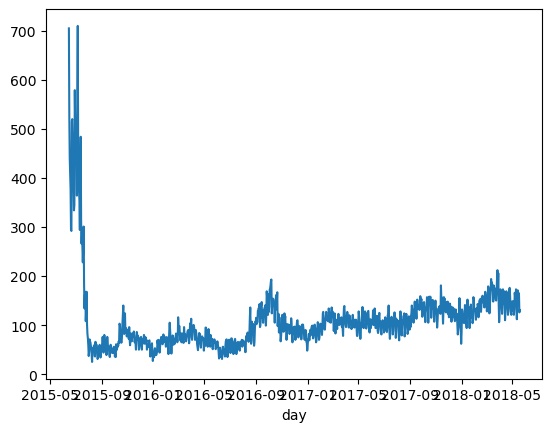

In [28]:
events_train.groupby('day')['user_id'].nunique().plot(kind='line')

Число активных пользователей на начало старта курса высокое, затем снижается, затем постепенно растет, что логично.

In [30]:
events_train

,step_id,timestamp,action,user_id,date,day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15
...,...,...,...,...,...,...
3480698,33375,1526772685,viewed,11677,2018-05-19 23:31:25,2018-05-19
3480699,32815,1526772750,viewed,5198,2018-05-19 23:32:30,2018-05-19
3480700,32815,1526772750,discovered,5198,2018-05-19 23:32:30,2018-05-19
3480701,32815,1526772750,passed,5198,2018-05-19 23:32:30,2018-05-19


In [31]:
events_train['user_id'].nunique()

19234

## Число прибывших пользователей по дням

In [33]:
events_train['min_day'] = events_train.groupby('user_id')['day'].min()

In [34]:
events_train.groupby('min_day')['user_id'].nunique()

min_day
2015-06-15    333
2015-06-16    174
2015-06-17    108
2015-06-18     88
2015-06-19     64
             ... 
2018-05-15     23
2018-05-16     24
2018-05-17     26
2018-05-18     17
2018-05-19     27
Name: user_id, Length: 1070, dtype: int64

In [35]:
sns.set(rc={'figure.figsize': (8, 6)})

<Axes: xlabel='min_day'>

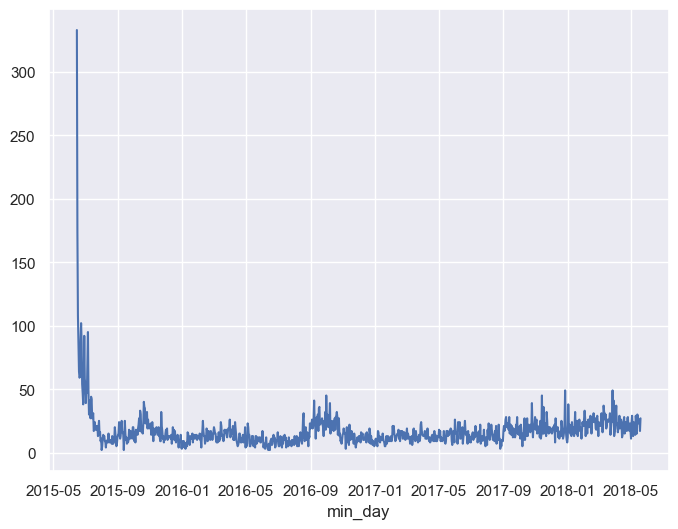

In [36]:
events_train.groupby('min_day')['user_id'].nunique().plot(kind='line', )

Число новоприбывших пользователей сначала высокое, затем снижается и остается примерно на одном уровне. Есть всплески в октябре-ноябре месяце. Возможно связано с учебным годом.

## Число пройденных степов по пользователям

In [39]:
events_train.head()

,step_id,timestamp,action,user_id,date,day,min_day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15,NaN
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15,2016-09-02
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15,2017-12-27
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15,NaN


<Axes: >

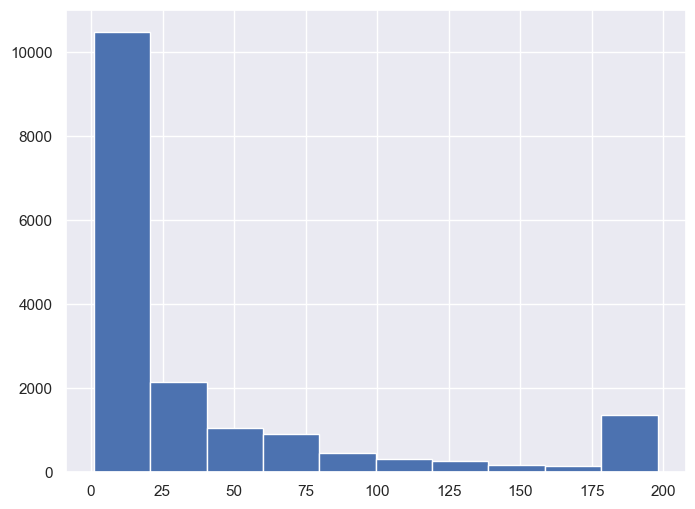

In [40]:
(events_train.query('action == "passed"').
 groupby('user_id', as_index=False).
 agg({'step_id':'nunique'}).
 rename(columns={'step_id':'passed_steps_count'})
 ['passed_steps_count'].hist()
)

Большое количество таких пользователей, у которых маленькое пройденное число степов. С увеличением числа пройденных степов, число пользователей снижается. Наблюдается отдельный бакет пользователей, которые прошли все степы.

In [42]:
t = (events_train.query('action == "passed"').
 groupby('user_id', as_index=False).
 agg({'step_id':'nunique'}).
 rename(columns={'step_id':'passed_steps_count'})
)
max_step = t['passed_steps_count'].max()
max_step

198

In [43]:
# число пользователей, прошедших курс до конца
finish_users = t.query('passed_steps_count == @max_step')['user_id'].count()
finish_users

394

In [44]:
user_nunique = events_train['user_id'].nunique()

In [45]:
# процент пользователей, прошедших курс до конца
(finish_users/user_nunique * 100).round(2)

2.05

`Проблема: при группировке мы не учли тех пользователей, у которых passed steps равно 0`

In [47]:
t['user_id'].nunique()

17262

In [48]:
events_train['user_id'].nunique()

19234

## Исправляем

In [50]:
events_train.head()

,step_id,timestamp,action,user_id,date,day,min_day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15,NaN
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15,2016-09-02
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15,2017-12-27
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15,NaN


`Теперь мы ничего не потеряли`

In [52]:
t = events_train.pivot_table(index='user_id', columns='action', values='step_id', aggfunc='count', fill_value = 0).reset_index()
t

action,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,10
2,3,91,87,30,192
3,5,11,11,4,12
4,7,1,1,0,1
...,...,...,...,...,...
19229,26790,8,8,1,9
19230,26793,1,0,1,1
19231,26794,69,69,34,180
19232,26797,10,10,2,13


# data preprocessing

Напомню себе, что в submissions_train данные по практическим степам (где нужно решить задачу)

In [55]:
submissions_train.head()

,step_id,timestamp,submission_status,user_id
0,31971,1434349275,correct,15853
1,31972,1434348300,correct,15853
2,31972,1478852149,wrong,15853
3,31972,1478852164,correct,15853
4,31976,1434348123,wrong,15853


In [56]:
submissions_train['date'] = pd.to_datetime(submissions_train.timestamp, unit='s')

In [57]:
submissions_train['day'] = submissions_train.date.dt.date

In [58]:
submissions_train.head()

,step_id,timestamp,submission_status,user_id,date,day
0,31971,1434349275,correct,15853,2015-06-15 06:21:15,2015-06-15
1,31972,1434348300,correct,15853,2015-06-15 06:05:00,2015-06-15
2,31972,1478852149,wrong,15853,2016-11-11 08:15:49,2016-11-11
3,31972,1478852164,correct,15853,2016-11-11 08:16:04,2016-11-11
4,31976,1434348123,wrong,15853,2015-06-15 06:02:03,2015-06-15


## users_scores

In [59]:
users_scores = submissions_train.pivot_table(index='user_id',
                        columns='submission_status',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0).reset_index()
users_scores.head()

submission_status,user_id,correct,wrong
0,2,2,0
1,3,29,23
2,5,2,2
3,8,9,21
4,14,0,1


In [60]:
max_wrong = users_scores['wrong'].max()
max_wrong

1001

In [61]:
users_scores[users_scores['wrong'] == max_wrong]

submission_status,user_id,correct,wrong
4579,12265,50,1001


## Замечание 

Комментарий  
надо взять стату закончевших курс, построить колокольчик (кол-во юзеров\ за скока дней юзер завершил курс). и взять число дней которое покрывает 90-95% закончивших пользователей = будет n дней. и считать что если кто то еще на этапе до n дней - то в процессе, иначе забил на курс

Давайте построим простые фичи для каждого пользователя. Посчитаем, скажем, сколько у него было уникальных степов, которые он прошёл. Сколько было правильных и неправильных сабмитов и сколько уникальных дней он учился на степике.

А дальше посмотрим различаются ли эти показатели для пользователей, успешно окончивших курс, и пользователей, которые курс бросили.

Здесь возникает важнй нюанс и то, как мы ответим на этот вопрос, будет полностью влиять на то какую задачу мы решаем и как.

Мы сейчас мысленно перенеслись в 2018-й год и у нас очень большой процент пользователей находится в процессе. Он мог зарегистрироваться неделю назад и 2 дня порешал, а потом 5 дней его не было.

Вопрос: этот пользователь бросил курс или нет? Нам нужно подгрузить ещё данных, чтобы проверить это?

С 5 днями понятно, а если речь идёт о 25 днях или больше.

С пользователями, которые прошли курс, т.е. получили сертификат, всё понятно.

Но есть ещё две важных группы пользователей:

- незакончившие курс вообще
- юзеры в процессе

Важно отличить эти две группы.

## Задача

Можно построить распределения перерывов между сабмитами у участников нашего курса. Если пользователь не появляется на нашем курсе больше, чем N дней, то с вероятностью 95% считаем его покинувшим курс.

Варьируя этот показатель можно обучать более жёсткие/более мягкие классификаторы. В дальнейшем нам это может пригодиться.

Подготовим наши данные, чтобы получился размеченный датасет. Те пользователи, которые закончили курс и дропнувшиеся пользователи. И несколько понятных фичей.

Теперь давайте подойдём к ещё одной очень важной теме - мы её уже затрагивали, и сейчас это ключевой момент для решения всей задачи. Мы хотим предсказывать тех пользователей, кторые дропнулись с курса. Которые не дорешали его до конца, ушли и больше не вернулись. У нас в данных нет какого-то показателя ушёл пользователь или нет. Более того, это понятие не совсем определено. 

Например человек не был на курсе уже две недели, хотя он зарегистрировался на курсе совсем недавно. 2 недели - это достаточно, чтобы считать его дропнувшимся? Или это принятая стратегия прохождения курсов - перерывы в две недели? 

На такой вопрос лучше отвечать на основе данных статистического анализа, а не просто взяв из головы некоторую эвристику, например, будем считать дропнувшимися всех пользователей, отсутствующих на курсе месяц. Почему месяц, а не два или три? Или наоборот почему не 3 или 2 недели?

Поэтому для ответа на этот вопрос проанализируем данные, которые у нас есть.

Одна из стратегий: Для каждого пользователя рассчитать какие у него были промежутки в перерывах между уникальными днями, когда он проходил курс. Далее посмотреть на картину по всем пользователям и принять статистическое решение.

Ответить на этот вопрос более статистически нам помогут данные events_data. Мы посмотрим как в среднем распределены перерывы в решении курса у юзеров. И, тем самым, ответим на вопрос - какой временной промежуток отсутствия на курсе можно считать пороговым, после которого мы будем считать пользователя дропнувшимся.

В течение дня может быть несколько событий с одним и тем же timestamp, но нам эта информация не нужна. Если человек хотя бы раз зашел в этот день будем считать его активным в этот день.

## Считаем порог, по которому будем считать, что пользователь ушел

In [72]:
events_train.head()

,step_id,timestamp,action,user_id,date,day,min_day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15,NaN
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15,2016-09-02
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15,2017-12-27
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15,NaN


In [73]:
t = events_train[['user_id', 'day', 'timestamp']].drop_duplicates(subset=['user_id', 'day'])
t

,user_id,day,timestamp
0,17632,2015-06-15,1434340848
36,12494,2015-06-15,1434341931
59,442,2015-06-15,1434342029
62,22254,2015-06-15,1434342042
94,6646,2015-06-15,1434342230
...,...,...,...
3480298,364,2018-05-19,1526762223
3480329,22851,2018-05-19,1526762629
3480333,943,2018-05-19,1526762664
3480669,26659,2018-05-19,1526770439


In [74]:
t.groupby('user_id')['timestamp'].apply(list)

user_id
1                                             [1472827464]
2                                 [1514383364, 1519226966]
3        [1434358476, 1441257725, 1441440209, 144153391...
5                                 [1466156809, 1499859621]
7                                             [1521634660]
                               ...                        
26790     [1451484016, 1451722241, 1452616205, 1517495853]
26793                                         [1510225031]
26794    [1495287049, 1495373177, 1495509936, 149560483...
26797                             [1508425316, 1509993306]
26798                                         [1520975763]
Name: timestamp, Length: 19234, dtype: object

In [75]:
np.diff([1, 3, 7])

array([2, 4])

In [76]:
t.groupby('user_id')['timestamp'].apply(list).apply(np.diff)

user_id
1                                                       []
2                                                [4843602]
3         [6899249, 182484, 93710, 2768870, 171400, 78712]
5                                               [33702812]
7                                                       []
                               ...                        
26790                           [238225, 893964, 64879648]
26793                                                   []
26794    [86128, 136759, 94899, 1422583, 14347289, 5050...
26797                                            [1567990]
26798                                                   []
Name: timestamp, Length: 19234, dtype: object

In [77]:
gap_data = t.groupby('user_id')['timestamp'].apply(list).apply(np.diff).values
gap_data

array([array([], dtype=int32), array([4843602]),
       array([6899249,  182484,   93710, 2768870,  171400,   78712]), ...,
       array([   86128,   136759,    94899,  1422583, 14347289,   505061,
                 98252,    57019])                                       ,
       array([1567990]), array([], dtype=int32)], dtype=object)

In [78]:
series_gap_data = pd.Series(np.concatenate(gap_data, axis=0))
series_gap_data

0         4843602
1         6899249
2          182484
3           93710
4         2768870
           ...   
97867    14347289
97868      505061
97869       98252
97870       57019
97871     1567990
Length: 97872, dtype: int32

In [79]:
# переводим в дни
series_gap_data = series_gap_data/(60*60*24)

In [80]:
series_gap_data

0         56.060208
1         79.852419
2          2.112083
3          1.084606
4         32.047106
            ...    
97867    166.056586
97868      5.845613
97869      1.137176
97870      0.659942
97871     18.148032
Length: 97872, dtype: float64

<Axes: >

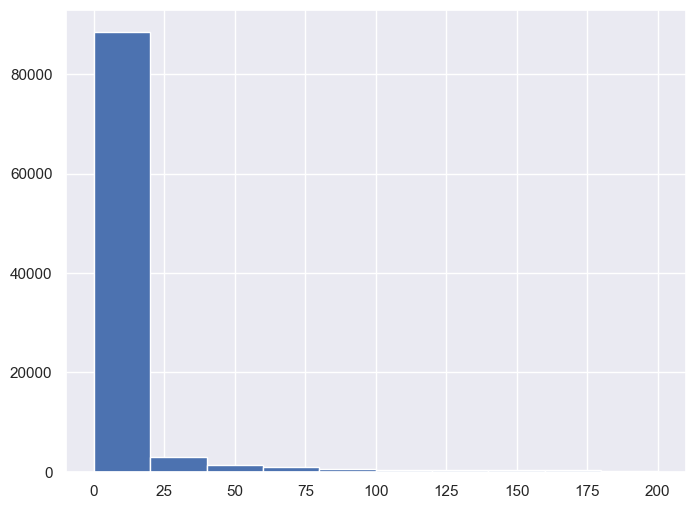

In [81]:
series_gap_data[series_gap_data<200].hist()

In [82]:
series_gap_data.quantile(0.95)

59.760440972222156

Т.е. у 95% пользователей разница между активными действиями на курсе меньше 59.8 дней. И только 5% пользователей возвращаются на курс после перерыва в 2 месяца. Т.е. был чел, который зашел на курс, потом зашел еще раз через более, чем 59.8 дней. таких пользователей 5%. Поэтому мы можем считать, что они ушли.

In [84]:
series_gap_data.quantile(0.9)

18.325995370370403

А 90% укладываются в интервал до 18 дней.

In [86]:
series_gap_data.quantile(0.925)

30.629370081018546

Мы можем взять значение 30 дней в качестве оценки между 90-м и 95-м процентилем.

## Практическое задание

In [142]:
submissions_train.head()

,step_id,timestamp,submission_status,user_id,date,day
0,31971,1434349275,correct,15853,2015-06-15 06:21:15,2015-06-15
1,31972,1434348300,correct,15853,2015-06-15 06:05:00,2015-06-15
2,31972,1478852149,wrong,15853,2016-11-11 08:15:49,2016-11-11
3,31972,1478852164,correct,15853,2016-11-11 08:16:04,2016-11-11
4,31976,1434348123,wrong,15853,2015-06-15 06:02:03,2015-06-15


In [148]:
(submissions_train.
 pivot_table(index='user_id', columns='submission_status', values='step_id', aggfunc='count').
 reset_index().
 sort_values(by='correct', ascending=False)
)

submission_status,user_id,correct,wrong
439,1046,421.0,513.0
2099,5552,186.0,93.0
6415,17135,168.0,177.0
2344,6183,142.0,65.0
3208,8461,135.0,42.0
...,...,...,...
9434,25472,NaN,1.0
9526,25727,NaN,1.0
9609,25914,NaN,4.0
9778,26349,NaN,1.0


## Считаем разницу между последним заходом и текущим днем

Теперь для каждого пользователя нужно понять, сколько времени прошло с момента его последнего посещения на текущий день.

Под текущим днём мы понимаем 19.05.2018

In [158]:
now = events_train['timestamp'].max()
now

1526772811

In [174]:
drop_out_threshold = series_gap_data.quantile(0.925) * 24 * 60 * 60
drop_out_threshold

2646377.575000002

In [192]:
# timestamp, когда пользователь заходил в последний раз
users_data = events_train.groupby('user_id', as_index=False).agg({'timestamp':'max'}).rename(columns={'timestamp':'last_timestamp'})
users_data

,user_id,last_timestamp
0,1,1472827464
1,2,1519226966
2,3,1444581588
3,5,1499859939
4,7,1521634660
...,...,...
19229,26790,1517495987
19230,26793,1510225034
19231,26794,1512035039
19232,26797,1509995096


In [194]:
# разница между текущей датой и (датой выгрузки данных) и датой последнего захода пользователя 
users_data['delta'] = (now - users_data['last_timestamp'])

In [196]:
# если разница больше отметки в 30 дней (threshold, соответствующий 95 процентилю), то пользователь ушел
users_data['is_gone_user'] = users_data['delta'] > drop_out_threshold

In [198]:
users_data

,user_id,last_timestamp,delta,is_gone_user
0,1,1472827464,53945347,True
1,2,1519226966,7545845,True
2,3,1444581588,82191223,True
3,5,1499859939,26912872,True
4,7,1521634660,5138151,True
...,...,...,...,...
19229,26790,1517495987,9276824,True
19230,26793,1510225034,16547777,True
19231,26794,1512035039,14737772,True
19232,26797,1509995096,16777715,True


In [184]:
users_data['is_gone_user'].value_counts()

is_gone_user
True     17820
False     1414
Name: count, dtype: int64

Теперь нужно уточнить, что эти пользователи не прошли курс и тогда задача будет решена. Т.е. есть пользователи, которые давно не заходили на курс, потому что уже прошли его. 

## Merge с таблицой практических задач

In [204]:
# users_scores сводная на основе данных submission_train (т.е. там только те пользователи, которые решали практические задачи)
users_scores

submission_status,user_id,correct,wrong
0,2,2,0
1,3,29,23
2,5,2,2
3,8,9,21
4,14,0,1
...,...,...,...
9935,26787,3,0
9936,26790,1,0
9937,26794,33,9
9938,26797,2,0


In [210]:
users_scores['user_id'].nunique()

9940

In [264]:
merge_df = users_data.merge(users_scores, how='left', on='user_id')
merge_df

,user_id,last_timestamp,delta,is_gone_user,correct,wrong
0,1,1472827464,53945347,True,NaN,NaN
1,2,1519226966,7545845,True,2.0,0.0
2,3,1444581588,82191223,True,29.0,23.0
3,5,1499859939,26912872,True,2.0,2.0
4,7,1521634660,5138151,True,NaN,NaN
...,...,...,...,...,...,...
19229,26790,1517495987,9276824,True,1.0,0.0
19230,26793,1510225034,16547777,True,NaN,NaN
19231,26794,1512035039,14737772,True,33.0,9.0
19232,26797,1509995096,16777715,True,2.0,0.0


## Замечание про passed

In [251]:
submissions_train.query('user_id == 15853 & step_id == 31972')

,step_id,timestamp,submission_status,user_id,date,day
1,31972,1434348300,correct,15853,2015-06-15 06:05:00,2015-06-15
2,31972,1478852149,wrong,15853,2016-11-11 08:15:49,2016-11-11
3,31972,1478852164,correct,15853,2016-11-11 08:16:04,2016-11-11


In [255]:
events_train.query('user_id == 15853 & step_id == 31972')

,step_id,timestamp,action,user_id,date,day,min_day
1915,31972,1434348247,discovered,15853,2015-06-15 06:04:07,2015-06-15,2016-02-08
1916,31972,1434348247,viewed,15853,2015-06-15 06:04:07,2015-06-15,2017-11-22
1917,31972,1434348257,started_attempt,15853,2015-06-15 06:04:17,2015-06-15,2015-06-30
1922,31972,1434348300,passed,15853,2015-06-15 06:05:00,2015-06-15,2017-01-17
1605458,31972,1478852086,viewed,15853,2016-11-11 08:14:46,2016-11-11,NaN
1605459,31972,1478852116,started_attempt,15853,2016-11-11 08:15:16,2016-11-11,NaN


т.е. passed при решении практического шага засчитывается один раз

## Merge с таблицей активностей

In [266]:
actives_data = events_train.pivot_table(index='user_id', columns='action', values='step_id', aggfunc='count', fill_value = 0).reset_index()

In [267]:
actives_data

action,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,10
2,3,91,87,30,192
3,5,11,11,4,12
4,7,1,1,0,1
...,...,...,...,...,...
19229,26790,8,8,1,9
19230,26793,1,0,1,1
19231,26794,69,69,34,180
19232,26797,10,10,2,13


In [270]:
full_data = merge_df.merge(actives_data, how='left', on='user_id')
full_data

,user_id,last_timestamp,delta,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed
0,1,1472827464,53945347,True,NaN,NaN,1,0,0,1
1,2,1519226966,7545845,True,2.0,0.0,9,9,2,10
2,3,1444581588,82191223,True,29.0,23.0,91,87,30,192
3,5,1499859939,26912872,True,2.0,2.0,11,11,4,12
4,7,1521634660,5138151,True,NaN,NaN,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...
19229,26790,1517495987,9276824,True,1.0,0.0,8,8,1,9
19230,26793,1510225034,16547777,True,NaN,NaN,1,0,1,1
19231,26794,1512035039,14737772,True,33.0,9.0,69,69,34,180
19232,26797,1509995096,16777715,True,2.0,0.0,10,10,2,13


In [274]:
full_data['passed_course'] = full_data['passed'] > 170

In [276]:
full_data.head()

,user_id,last_timestamp,delta,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,passed_course
0,1,1472827464,53945347,True,NaN,NaN,1,0,0,1,False
1,2,1519226966,7545845,True,2.0,0.0,9,9,2,10,False
2,3,1444581588,82191223,True,29.0,23.0,91,87,30,192,False
3,5,1499859939,26912872,True,2.0,2.0,11,11,4,12,False
4,7,1521634660,5138151,True,NaN,NaN,1,1,0,1,False


In [280]:
full_data['passed_course'].value_counts(normalize=True)

passed_course
False    0.925912
True     0.074088
Name: proportion, dtype: float64

In [290]:
users_day = events_train.groupby('user_id')['day'].nunique().to_frame().reset_index()
users_day

,user_id,day
0,1,1
1,2,2
2,3,7
3,5,2
4,7,1
...,...,...
19229,26790,4
19230,26793,1
19231,26794,9
19232,26797,2


In [292]:
full_data = full_data.merge(users_day, on='user_id', how='left')

In [294]:
full_data

,user_id,last_timestamp,delta,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,passed_course,day
0,1,1472827464,53945347,True,NaN,NaN,1,0,0,1,False,1
1,2,1519226966,7545845,True,2.0,0.0,9,9,2,10,False,2
2,3,1444581588,82191223,True,29.0,23.0,91,87,30,192,False,7
3,5,1499859939,26912872,True,2.0,2.0,11,11,4,12,False,2
4,7,1521634660,5138151,True,NaN,NaN,1,1,0,1,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...
19229,26790,1517495987,9276824,True,1.0,0.0,8,8,1,9,False,4
19230,26793,1510225034,16547777,True,NaN,NaN,1,0,1,1,False,1
19231,26794,1512035039,14737772,True,33.0,9.0,69,69,34,180,False,9
19232,26797,1509995096,16777715,True,2.0,0.0,10,10,2,13,False,2


# Модель

## Среднее число уникальных дней (когда что-то смотрели или решали) на курсе, у тех кто завершил курс

In [301]:
full_data.query('passed_course == True')['day'].median()

20.0

<Axes: ylabel='Frequency'>

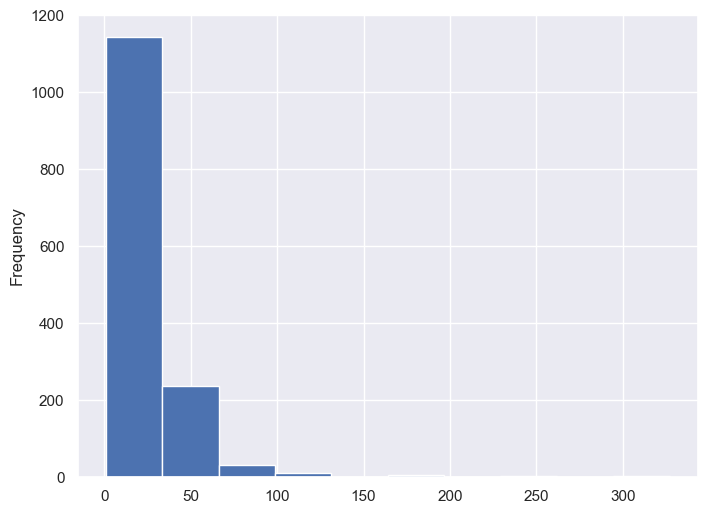

In [311]:
full_data.query('passed_course == True')['day'].plot(kind='hist')

Половина пользователей решает более 20 дней. Поэтому возьмем порог в 3 дня (хз, так в видео сказали) 

In [317]:
full_data

,user_id,last_timestamp,delta,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,passed_course,day
0,1,1472827464,53945347,True,NaN,NaN,1,0,0,1,False,1
1,2,1519226966,7545845,True,2.0,0.0,9,9,2,10,False,2
2,3,1444581588,82191223,True,29.0,23.0,91,87,30,192,False,7
3,5,1499859939,26912872,True,2.0,2.0,11,11,4,12,False,2
4,7,1521634660,5138151,True,NaN,NaN,1,1,0,1,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...
19229,26790,1517495987,9276824,True,1.0,0.0,8,8,1,9,False,4
19230,26793,1510225034,16547777,True,NaN,NaN,1,0,1,1,False,1
19231,26794,1512035039,14737772,True,33.0,9.0,69,69,34,180,False,9
19232,26797,1509995096,16777715,True,2.0,0.0,10,10,2,13,False,2


## Минимальный timestamp пользователя

In [328]:
min_timestamp_data = (events_train.
                      groupby('user_id', as_index=False).
                      agg({'timestamp':'min'}).
                      rename(columns={'timestamp':'min_timestamp'}))

In [330]:
full_data.merge(min_timestamp_data, on='user_id', how='left')

,user_id,last_timestamp,delta,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,passed_course,day,min_timestamp
0,1,1472827464,53945347,True,NaN,NaN,1,0,0,1,False,1,1472827464
1,2,1519226966,7545845,True,2.0,0.0,9,9,2,10,False,2,1514383364
2,3,1444581588,82191223,True,29.0,23.0,91,87,30,192,False,7,1434358476
3,5,1499859939,26912872,True,2.0,2.0,11,11,4,12,False,2,1466156809
4,7,1521634660,5138151,True,NaN,NaN,1,1,0,1,False,1,1521634660
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19229,26790,1517495987,9276824,True,1.0,0.0,8,8,1,9,False,4,1451484016
19230,26793,1510225034,16547777,True,NaN,NaN,1,0,1,1,False,1,1510225031
19231,26794,1512035039,14737772,True,33.0,9.0,69,69,34,180,False,9,1495287049
19232,26797,1509995096,16777715,True,2.0,0.0,10,10,2,13,False,2,1508425316


## Действия каждого пользователя в его первые 3 дня на курсе

In [344]:
timestamp_threshold = 3 * 24 * 60 * 60
timestamp_threshold

259200

In [338]:
events_train = events_train.merge(min_timestamp_data, on='user_id', how='left')

In [346]:
events_train.head()

,step_id,timestamp,action,user_id,date,day,min_day,min_timestamp
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15,NaN,1434340848
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15,2016-09-02,1434340848
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15,2017-12-27,1434340848
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15,2015-06-15,1434340848
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15,NaN,1434340848


In [348]:
events_train['min_timestamp'] + timestamp_threshold

0          1434600048
1          1434600048
2          1434600048
3          1434600048
4          1434600048
              ...    
3480698    1511617409
3480699    1527031950
3480700    1527031950
3480701    1527031950
3480702    1523900045
Name: min_timestamp, Length: 3480703, dtype: int64

In [363]:
days_3_data = events_train.query("timestamp < min_timestamp + @timestamp_threshold")
days_3_data = days_3_data.drop('min_day', axis=1)
days_3_data

,step_id,timestamp,action,user_id,date,day,min_timestamp
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15,1434340848
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15,1434340848
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15,1434340848
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15,1434340848
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15,1434340848
...,...,...,...,...,...,...,...
3480530,32953,1526766998,viewed,24555,2018-05-19 21:56:38,2018-05-19,1526729867
3480531,32953,1526766998,discovered,24555,2018-05-19 21:56:38,2018-05-19,1526729867
3480699,32815,1526772750,viewed,5198,2018-05-19 23:32:30,2018-05-19,1526772750
3480700,32815,1526772750,discovered,5198,2018-05-19 23:32:30,2018-05-19,1526772750


## Практическое задание

Давайте найдем такой стэп, используя данные о сабмитах. Для каждого пользователя найдите такой шаг, который он не смог решить, и после этого не пытался решать другие шаги. Затем найдите id шага,  который стал финальной точкой практического обучения на курсе для максимального числа пользователей. 

То есть мы исследуем следующий сценарий: человек решает стэп, не может получить правильный ответ и больше не возвращается к практическим задачам. Что это за шаг такой, который отпугнул максимальное число пользователей?

In [383]:
last_timestamp = (submissions_train.
                  groupby('user_id', as_index=False).
                  agg({'timestamp':'max'}).
                  rename(columns={'timestamp':'last_timestamp'})
                 )

In [389]:
submissions_train_hard = submissions_train.merge(last_timestamp, on='user_id', how='left')
submissions_train_hard.head()

,step_id,timestamp,submission_status,user_id,date,day,last_timestamp
0,31971,1434349275,correct,15853,2015-06-15 06:21:15,2015-06-15,1479734163
1,31972,1434348300,correct,15853,2015-06-15 06:05:00,2015-06-15,1479734163
2,31972,1478852149,wrong,15853,2016-11-11 08:15:49,2016-11-11,1479734163
3,31972,1478852164,correct,15853,2016-11-11 08:16:04,2016-11-11,1479734163
4,31976,1434348123,wrong,15853,2015-06-15 06:02:03,2015-06-15,1479734163


In [407]:
(submissions_train_hard.
 query('timestamp == last_timestamp & submission_status == "wrong"').
 groupby('step_id', as_index=False).
 agg({'user_id':'count'}).
 rename(columns={'user_id':'count_user_id'}).
 sort_values(by='count_user_id', ascending=False)
)

,step_id,count_user_id
4,31978,154
28,32812,133
11,32031,97
19,32202,92
42,33481,78
...,...,...
43,33482,1
59,33686,1
57,33684,1
55,33676,1


## Проверка

In [417]:
days_3_data.groupby('user_id')['day'].nunique().max()

4

## Сабмиты каждого пользователя в первые 3 дня на курсе

In [460]:
submissions_train.head()

,step_id,timestamp,submission_status,user_id,date,day,min_timestamp
0,31971,1434349275,correct,15853,2015-06-15 06:21:15,2015-06-15,1434346056
1,31972,1434348300,correct,15853,2015-06-15 06:05:00,2015-06-15,1434346056
2,31972,1478852149,wrong,15853,2016-11-11 08:15:49,2016-11-11,1434346056
3,31972,1478852164,correct,15853,2016-11-11 08:16:04,2016-11-11,1434346056
4,31976,1434348123,wrong,15853,2015-06-15 06:02:03,2015-06-15,1434346056


In [445]:
min_timestamp_sub = (submissions_train.
                      groupby('user_id', as_index=False).
                      agg({'timestamp':'min'}).
                      rename(columns={'timestamp':'min_timestamp'}))
min_timestamp_sub

,user_id,min_timestamp
0,2,1514383420
1,3,1434358533
2,5,1499859650
3,8,1480603432
4,14,1436368601
...,...,...
9935,26787,1469014806
9936,26790,1451722691
9937,26794,1495290798
9938,26797,1508425367


In [451]:
submissions_train = submissions_train.merge(min_timestamp_sub, on='user_id', how='left')

In [455]:
days_3_submissions = submissions_train.query("timestamp < min_timestamp + @timestamp_threshold")
days_3_submissions.head()

,step_id,timestamp,submission_status,user_id,date,day,min_timestamp
0,31971,1434349275,correct,15853,2015-06-15 06:21:15,2015-06-15,1434346056
1,31972,1434348300,correct,15853,2015-06-15 06:05:00,2015-06-15,1434346056
4,31976,1434348123,wrong,15853,2015-06-15 06:02:03,2015-06-15,1434346056
5,31976,1434348188,correct,15853,2015-06-15 06:03:08,2015-06-15,1434346056
7,31977,1434347371,correct,15853,2015-06-15 05:49:31,2015-06-15,1434346056


In [464]:
days_3_sub_info = (days_3_submissions.
                   pivot_table(index='user_id', columns='submission_status', values='step_id', aggfunc='count', fill_value = 0).
                   reset_index()
                  )
days_3_sub_info

submission_status,user_id,correct,wrong
0,2,2,0
1,3,4,4
2,5,2,2
3,8,9,21
4,14,0,1
...,...,...,...
9935,26787,3,0
9936,26790,1,0
9937,26794,31,9
9938,26797,2,0


## Создаем features

In [425]:
days_3_data.head()

,step_id,timestamp,action,user_id,date,day,min_timestamp
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15,1434340848
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15,1434340848
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15,1434340848
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15,1434340848
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15,1434340848


In [462]:
X = (days_3_submissions.
     groupby('user_id').
     agg({'day':'nunique', 
          'step_id':'nunique'}).
     rename(columns = {'step_id':'steps_tried'})
)
X

,day,steps_tried
user_id,,
2,1,2
3,1,4
5,1,2
8,1,11
14,1,1
...,...,...
26787,1,3
26790,1,1
26794,3,27


In [468]:
X = X.merge(days_3_sub_info, on='user_id', how='left')

In [482]:
X['correct_ratio'] = (X['correct']/(X['correct']+X['wrong'])).round(2)

In [484]:
X

,user_id,day,steps_tried,correct,wrong,correct_ratio
0,2,1,2,2,0,1.00
1,3,1,4,4,4,0.50
2,5,1,2,2,2,0.50
3,8,1,11,9,21,0.30
4,14,1,1,0,1,0.00
...,...,...,...,...,...,...
9935,26787,1,3,3,0,1.00
9936,26790,1,1,1,0,1.00
9937,26794,3,27,31,9,0.78
9938,26797,1,2,2,0,1.00


In [494]:
viewed_data = (days_3_data.
               pivot_table(index='user_id', columns='action', values='step_id', aggfunc='count', fill_value = 0).
               reset_index()
               [['user_id', 'viewed']]
              )
viewed_data

action,user_id,viewed
0,1,1
1,2,9
2,3,20
3,5,1
4,7,1
...,...,...
19229,26790,6
19230,26793,1
19231,26794,134
19232,26797,10


In [498]:
X = X.merge(viewed_data, on='user_id', how='left')

In [506]:
X

,user_id,day,steps_tried,correct,wrong,correct_ratio,viewed
0,2,1,2,2,0,1.00,9
1,3,1,4,4,4,0.50,20
2,5,1,2,2,2,0.50,1
3,8,1,11,9,21,0.30,154
4,14,1,1,0,1,0.00,9
...,...,...,...,...,...,...,...
9935,26787,1,3,3,0,1.00,14
9936,26790,1,1,1,0,1.00,6
9937,26794,3,27,31,9,0.78,134
9938,26797,1,2,2,0,1.00,10


In [516]:
X = X.merge(full_data[['user_id', 'is_gone_user', 'passed_course']], on='user_id', how='left')

In [520]:
X.head()

,user_id,day,steps_tried,correct,wrong,correct_ratio,viewed,is_gone_user,passed_course
0,2,1,2,2,0,1.0,9,True,False
1,3,1,4,4,4,0.5,20,True,False
2,5,1,2,2,2,0.5,1,True,False
3,8,1,11,9,21,0.3,154,True,False
4,14,1,1,0,1,0.0,9,True,False


## Пользователи, которые не закончили курс и еще не ушли. Таких мы не учитываем

In [525]:
X[(X['is_gone_user'] == False) & (X['passed_course'] == False)]

,user_id,day,steps_tried,correct,wrong,correct_ratio,viewed,is_gone_user,passed_course
8,25,1,2,1,4,0.20,40,False,False
12,32,1,3,3,0,1.00,14,False,False
22,57,3,13,13,28,0.32,70,False,False
32,78,1,2,2,0,1.00,13,False,False
60,156,1,2,2,0,1.00,10,False,False
...,...,...,...,...,...,...,...,...,...
9828,26501,1,2,2,0,1.00,16,False,False
9840,26543,3,23,22,39,0.36,78,False,False
9847,26558,3,29,29,12,0.71,80,False,False
9882,26661,1,1,1,0,1.00,4,False,False


## Пользователи, которые либо закончили курс, либо ушли с него

In [530]:
X = X[~((X['is_gone_user'] == False) & (X['passed_course'] == False))]

In [534]:
X.head()

,user_id,day,steps_tried,correct,wrong,correct_ratio,viewed,is_gone_user,passed_course
0,2,1,2,2,0,1.0,9,True,False
1,3,1,4,4,4,0.5,20,True,False
2,5,1,2,2,2,0.5,1,True,False
3,8,1,11,9,21,0.3,154,True,False
4,14,1,1,0,1,0.0,9,True,False


## Финальный датасет для обучения

In [544]:
y = X[['user_id', 'passed_course']].set_index('user_id').astype(int)

In [550]:
y

,passed_course
user_id,
2,0
3,0
5,0
8,0
14,0
...,...
26787,0
26790,0
26794,0


In [554]:
X = X.drop(['is_gone_user', 'passed_course'], axis=1)

In [558]:
X = X.set_index('user_id')

Описание переменных
- day - число дней на курсе (уникальных)
- steps_tried - число пройденных степов (как теория, так и практика)
- correct - число верных практических степов
- wrong - число неверных практических степов
- correct_ratio - скор верных ответов
- viewed - число просмотренных степов

In [560]:
X

,day,steps_tried,correct,wrong,correct_ratio,viewed
user_id,,,,,,
2,1,2,2,0,1.00,9
3,1,4,4,4,0.50,20
5,1,2,2,2,0.50,1
8,1,11,9,21,0.30,154
14,1,1,0,1,0.00,9
...,...,...,...,...,...,...
26787,1,3,3,0,1.00,14
26790,1,1,1,0,1.00,6
26794,3,27,31,9,0.78,134
